In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/CleanedSalesData.csv')
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,...,Avg_Item_Price,Discount_Percentage,Cost_Price,Profit,Profit_Margin,Cart_Size,Engagement_Score,Pages_Per_Minute,Is_Delayed,Rating_Category
0,ORD_000001-1,CUST_00001,2023-05-28,40,Male,Delhi (NCR),Books,29.18,1,0.00,...,29.18,0.000000,20.426,8.754,0.300000,1,126,0.642857,1,Medium
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Delhi (NCR),Home & Garden,644.40,1,138.05,...,506.35,0.214230,451.080,55.270,0.109154,1,112,0.571429,0,Low
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Delhi (NCR),Sports,332.82,5,0.00,...,332.82,0.000000,232.974,1431.126,0.860000,5,150,0.666667,1,Medium
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Bengaluru,Food,69.30,5,71.05,...,55.09,0.205051,48.510,226.940,0.823888,5,208,0.812500,0,Medium
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Bengaluru,Beauty,178.15,3,0.00,...,178.15,0.000000,124.705,409.745,0.766667,3,98,0.500000,0,Medium


In [3]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=[object]).columns.tolist()
    

In [4]:
numerical_features

['Age',
 'Unit_Price',
 'Quantity',
 'Discount_Amount',
 'Total_Amount',
 'Session_Duration_Minutes',
 'Pages_Viewed',
 'Delivery_Time_Days',
 'Customer_Rating',
 'Total_Sales',
 'Avg_Item_Price',
 'Discount_Percentage',
 'Cost_Price',
 'Profit',
 'Profit_Margin',
 'Cart_Size',
 'Engagement_Score',
 'Pages_Per_Minute',
 'Is_Delayed']

In [5]:
categorical_features

['Order_ID',
 'Customer_ID',
 'Date',
 'Gender',
 'City',
 'Product_Category',
 'Payment_Method',
 'Device_Type',
 'Rating_Category']

# Exploratory Data Analysis (EDA)

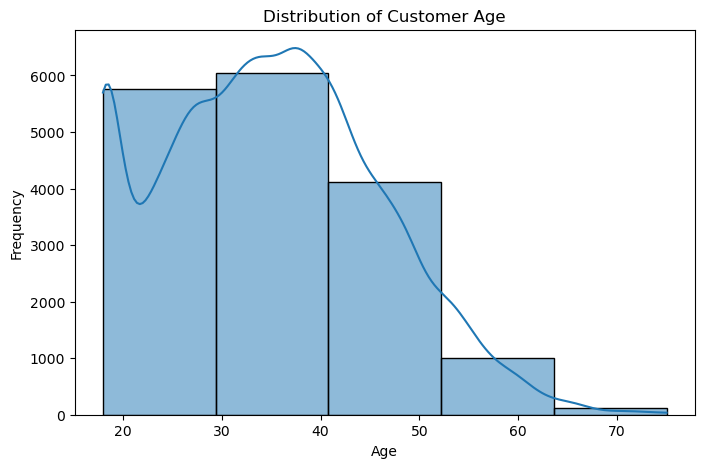

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=5, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [9]:
df['City'].value_counts()

City
Bengaluru      4402
Delhi (NCR)    2422
Mumbai         2072
Hyderabad      1721
Pune           1326
Chennai        1246
Kolkata        1183
Ahmedabad      1120
Lucknow         851
Jaipur          706
Name: count, dtype: int64

In [7]:
print("Earliest Date:", df["Date"].min())
print("Latest Date:", df["Date"].max())

Earliest Date: 2023-01-01
Latest Date: 2024-03-25


In [8]:
df['Product_Category'].value_counts()

Product_Category
Sports           2248
Beauty           2212
Books            2206
Food             2103
Toys             2090
Electronics      2074
Home & Garden    2060
Fashion          2056
Name: count, dtype: int64

NameError: name 'OUT_DIR' is not defined

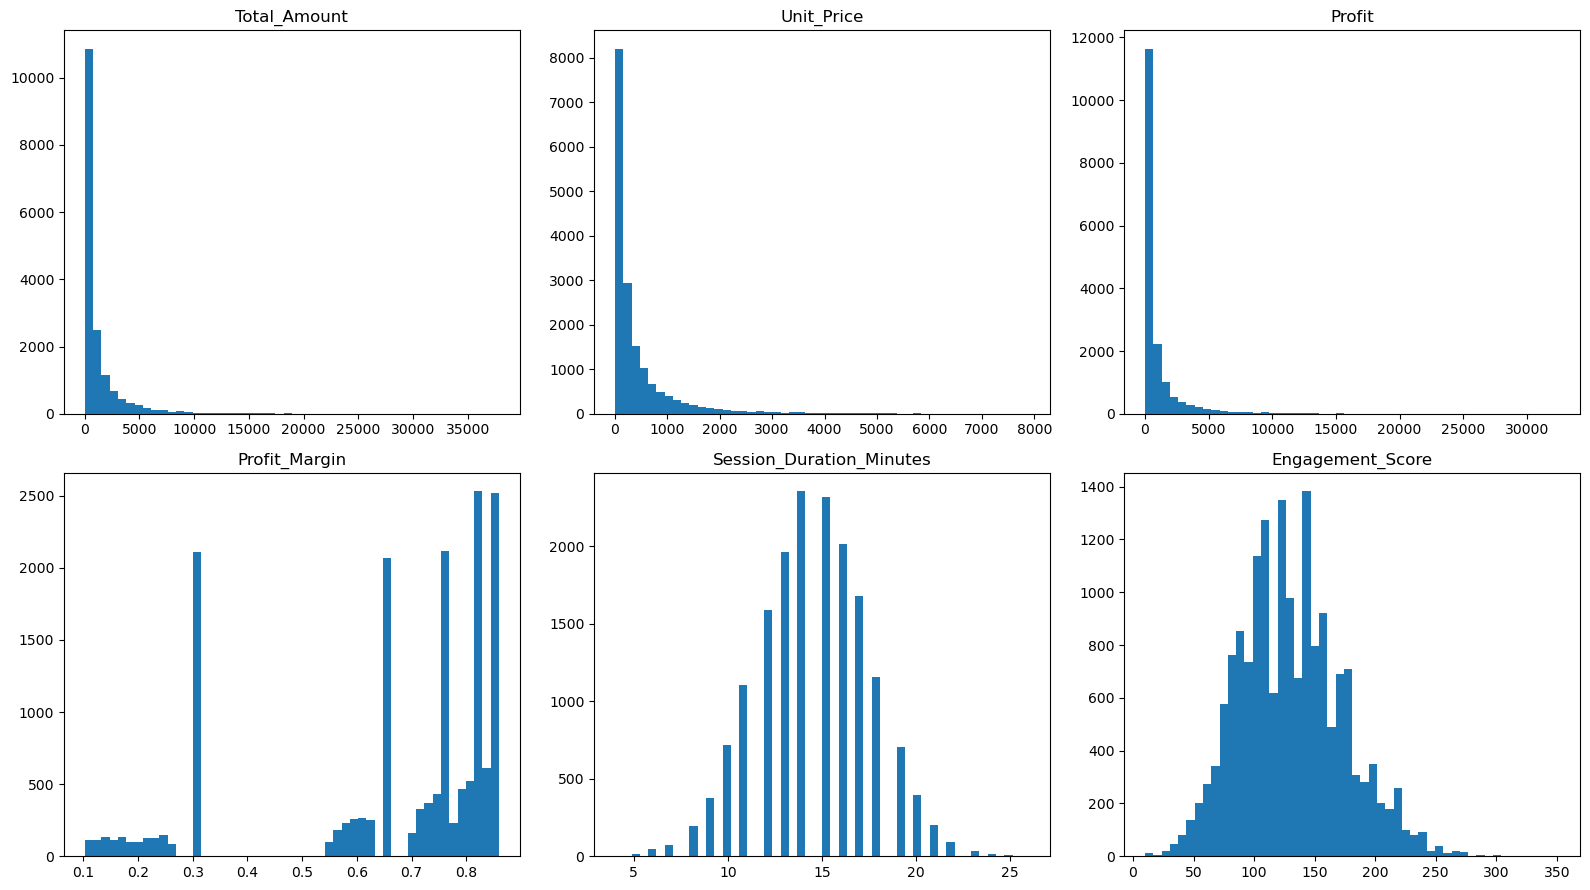

In [13]:
key_numeric = [c for c in ['Total_Amount','Unit_Price','Profit','Profit_Margin',
                            'Session_Duration_Minutes','Engagement_Score'] if c in df.columns]
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), key_numeric):
    ax.hist(df[col], bins=50)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/01_distributions.png', dpi=150)
plt.close()